# Machine Learning - Project 1: Classification

This notebook presents a complete binary classification workflow for weather prediction, from exploratory analysis to tuned model evaluation and final test prediction export.


## Integrity Note

The dataset is used as provided, without external data enrichment.


Author: Giannis Mavromatis

## 1. Dataset Introduction

Load and inspect the training-validation dataset.


### 1.a Load `train-val.csv`

Read the dataset into a pandas DataFrame.


This step initializes the working DataFrame used throughout the notebook.


In [28]:
import pandas as pd


# Replace 'your_file.csv' with the name of your CSV file
df = pd.read_csv('train-val.csv')

Use code to present:

- Total number of samples and features
- Feature data types
- Feature names
- Number of target classes
- Class distribution
- Numeric feature correlations
- Additional diagnostics


The following tasks summarize the exploratory analysis targets before preprocessing.


In [29]:
#2a
# Display the number of samples (rows) and features (columns)
num_samples, num_features = df.shape
print("Number of samples:", num_samples)
print("Number of features:", num_features)

#The df.shape attribute in pandas provides the dimensions of the DataFrame df. It returns a tuple (rows, columns) where: 
# rows is the number of samples (rows) in the dataset.
#columns is the number of features (columns) in the dataset.

Number of samples: 7262
Number of features: 24


In [30]:
#2b
# Display the data types of each feature
feature_types = df.dtypes
print("Feature Types:")
print(feature_types)

#The output will show each column name and its data type, helping you understand whether the features are numerical (e.g., int64, float64), categorical (e.g., object), or other types (eg `datetime64` for date-time values, which could indicate specific time-based information).

Feature Types:
ID                 int64
Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday          int64
RainTomorrow       int64
dtype: object


In [31]:
#2c
# Display the feature labels (column names)
feature_labels = df.columns
print("Feature Labels:")
print(feature_labels)


Feature Labels:
Index(['ID', 'Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall',
       'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am',
       'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')


In [32]:
#2d
print("Totally, there are",df['RainTomorrow'].nunique()," unique categories, with the possible values being:",df['RainTomorrow'].unique())

Totally, there are 2  unique categories, with the possible values being: [0 1]


In [33]:
#2e Count sample sizes for each category
# Display the total sample count once
df['RainTomorrow'].value_counts()

RainTomorrow
0    5623
1    1639
Name: count, dtype: int64

                     ID   MinTemp   MaxTemp  Rainfall  Evaporation  Sunshine  \
ID             1.000000  0.101510  0.133521 -0.032217     0.071010  0.051325   
MinTemp        0.101510  1.000000  0.709894  0.093915     0.460272  0.064273   
MaxTemp        0.133521  0.709894  1.000000 -0.098454     0.571740  0.469705   
Rainfall      -0.032217  0.093915 -0.098454  1.000000    -0.074776 -0.182762   
Evaporation    0.071010  0.460272  0.571740 -0.074776     1.000000  0.348179   
Sunshine       0.051325  0.064273  0.469705 -0.182762     0.348179  1.000000   
WindGustSpeed  0.043297  0.165904  0.008927  0.182268     0.168108 -0.068132   
WindSpeed9am   0.069138  0.199696  0.009758  0.127017     0.207150  0.020779   
WindSpeed3pm   0.030900  0.192065  0.057063  0.093557     0.135517  0.047236   
Humidity9am   -0.117635 -0.227187 -0.485498  0.204239    -0.502250 -0.463217   
Humidity3pm   -0.075666  0.023297 -0.493780  0.235734    -0.373950 -0.621705   
Pressure9am   -0.084635 -0.366575 -0.217

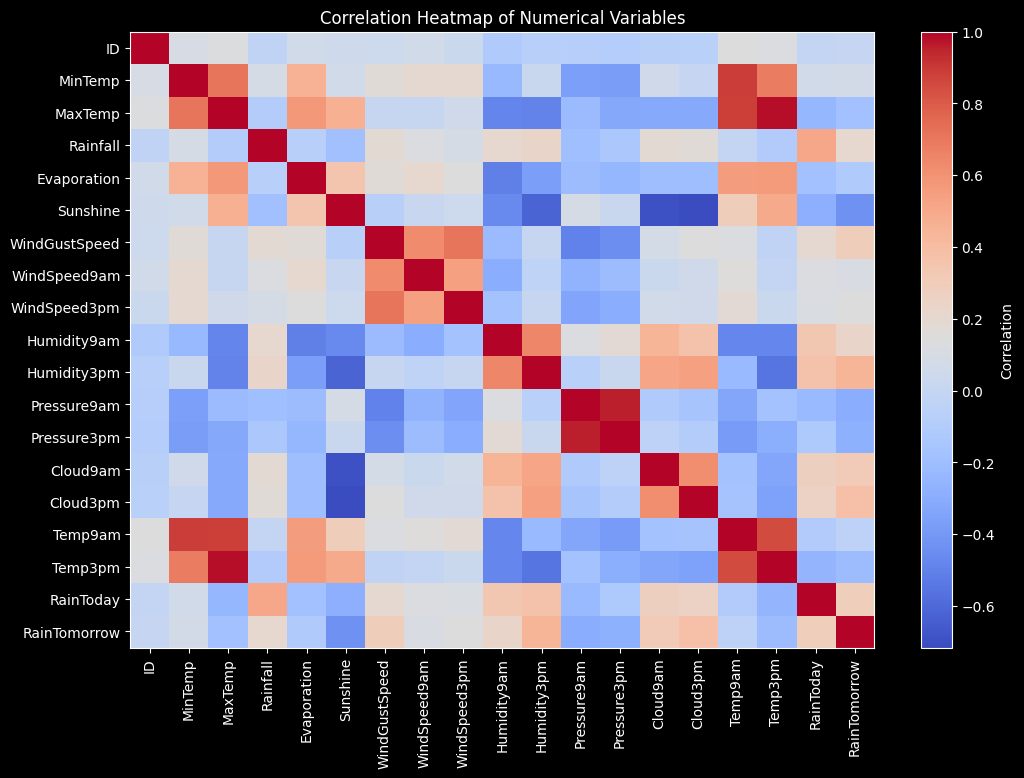

In [34]:
#2f. Feature correlation
import matplotlib.pyplot as plt
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix for numerical columns only
correlation_matrix = numeric_df.corr()
print(correlation_matrix)




# Plot the correlation matrix as a heatmap (matplotlib only)
plt.figure(figsize=(12, 8))
plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()


In [35]:
# 2g Other valid properties.


# Overview of the Dataset
# Display the first few rows of the dataset
print("Dataset Preview:")
display(df.head())



#####################################################################

# #Missing Values Analysis
# 
# # Calculate the percentage of missing values in each column
# missing_values = df.isnull().mean() * 100
# missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
# print("Missing Values Percentage by Column:")
# print(missing_values)
# 
# #############################################################################
# 
# #Distribution of Numerical Features
# 
# import matplotlib.pyplot as plt
# 
# # Plot histograms for each numerical column
# numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
# 
# df[numeric_columns].hist(bins=20, figsize=(15, 10))
# plt.suptitle("Distribution of Numerical Features")
# plt.show()


############################################################################################

#Distribution of Categorical Features


# # Plot bar charts for each categorical column
# categorical_columns = df.select_dtypes(include=['object']).columns
# 
# for column in categorical_columns:
# plt.figure(figsize=(8, 4))
# df[column].value_counts().plot(kind='bar')
# plt.title(f"Distribution of {column}")
# plt.xlabel(column)
# plt.ylabel("Frequency")
# plt.show()
# 
# 
# ##################################################################################################
# 
# #Outlier Detection
# 
# # Plot boxplots for each numerical column
# for column in numeric_columns:
# plt.figure(figsize=(8, 4))
# sns.boxplot(data=df, x=column)
# plt.title(f"Boxplot of {column}")
# plt.show()


####################################################################################################

# Relationships Between Numerical and Categorical Variables


# Example: Replace 'CategoryColumn' with your categorical column
# and loop through all categorical columns with significant numerical values

# for cat_column in categorical_columns:
# for num_column in numeric_columns:
# plt.figure(figsize=(10, 6))
# sns.boxplot(data=df, x=cat_column, y=num_column)
# plt.title(f"Relationship between {cat_column} and {num_column}")
# plt.show()

Dataset Preview:


,ID,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,3423,2016-03-04,Tuggeranong,14.4,32.2,11.0,NaN,NaN,NE,22.0,...,81.0,32.0,1021.6,1018.0,NaN,NaN,18.4,31.2,1,0
1,6095,2013-06-23,GoldCoast,11.0,21.5,0.0,NaN,NaN,S,43.0,...,64.0,58.0,1024.1,1021.2,NaN,NaN,17.1,20.2,0,0
2,403,2009-07-05,Cobar,8.3,14.7,0.0,2.4,7.4,SSW,24.0,...,79.0,55.0,1021.8,1019.7,7.0,6.0,10.6,14.0,0,0
3,333,2014-10-12,BadgerysCreek,8.8,32.2,0.0,NaN,NaN,ENE,37.0,...,65.0,18.0,1017.5,1011.7,NaN,NaN,17.7,30.9,0,0
4,2085,2012-07-04,Sydney,7.2,16.2,0.0,3.6,6.4,NaN,NaN,...,55.0,43.0,1024.6,1025.1,3.0,7.0,9.6,15.9,0,1


In [36]:
# Get information on columns, data types, and non-null counts
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7262 entries, 0 to 7261
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             7262 non-null   int64  
 1   Date           7262 non-null   object 
 2   Location       7262 non-null   object 
 3   MinTemp        7237 non-null   float64
 4   MaxTemp        7251 non-null   float64
 5   Rainfall       7262 non-null   float64
 6   Evaporation    4223 non-null   float64
 7   Sunshine       3817 non-null   float64
 8   WindGustDir    6787 non-null   object 
 9   WindGustSpeed  6789 non-null   float64
 10  WindDir9am     6692 non-null   object 
 11  WindDir3pm     7049 non-null   object 
 12  WindSpeed9am   7207 non-null   float64
 13  WindSpeed3pm   7128 non-null   float64
 14  Humidity9am    7185 non-null   float64
 15  Humidity3pm    7094 non-null   float64
 16  Pressure9am    6576 non-null   float64
 17  Pressure3pm    6575 non-null   float64

In [37]:
# Get summary statistics for numerical columns
print("Summary Statistics (Numerical Columns):")
display(df.describe())

Summary Statistics (Numerical Columns):


,ID,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
count,7262.000000,7237.000000,7251.000000,7262.000000,4223.000000,3817.000000,6789.000000,7207.000000,7128.000000,7185.000000,7094.000000,6576.000000,6575.000000,4592.000000,4443.000000,7228.000000,7142.000000,7262.000000,7262.000000
mean,4849.619113,10.638345,21.524562,2.302782,4.699005,7.356930,39.160701,13.674622,18.227273,70.242171,52.359459,1018.909367,1016.469262,4.368467,4.489534,15.426204,20.081686,0.228863,0.225695
std,2787.027799,5.994250,6.482395,8.027407,3.761805,3.539593,13.846248,8.918759,8.858489,18.807468,20.012168,7.061870,6.988741,2.909982,2.714390,6.079540,6.367390,0.420130,0.418068
min,2.000000,-7.600000,-3.700000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,2.000000,1.000000,990.800000,989.900000,0.000000,0.000000,-5.200000,-4.100000,0.000000,0.000000
25%,2441.500000,6.400000,16.900000,0.000000,2.200000,4.900000,30.000000,7.000000,11.000000,58.000000,38.000000,1014.300000,1011.800000,1.000000,2.000000,11.200000,15.600000,0.000000,0.000000
50%,4857.000000,10.300000,20.800000,0.000000,4.000000,8.200000,37.000000,13.000000,17.000000,71.000000,53.000000,1019.000000,1016.600000,5.000000,5.000000,14.900000,19.300000,0.000000,0.000000
75%,7245.750000,14.500000,25.800000,0.800000,6.400000,10.200000,46.000000,19.000000,24.000000,85.000000,66.000000,1023.600000,1021.200000,7.000000,7.000000,19.300000,24.200000,0.000000,0.000000
max,9683.000000,28.100000,42.800000,174.600000,50.800000,13.600000,104.000000,65.000000,83.000000,100.000000,100.000000,1040.200000,1036.700000,8.000000,9.000000,36.500000,41.700000,1.000000,1.000000


In [38]:
# Get summary statistics for categorical columns
print("Summary Statistics (Categorical Columns):")
display(df.describe(include=['object']))

Summary Statistics (Categorical Columns):


,Date,Location,WindGustDir,WindDir9am,WindDir3pm
count,7262,7262,6787,6692,7049
unique,2268,49,16,16,16
top,2010-06-01,Brisbane,W,N,W
freq,10,184,546,611,554


In [39]:
print(df.isnull().sum())

ID                  0
Date                0
Location            0
MinTemp            25
MaxTemp            11
Rainfall            0
Evaporation      3039
Sunshine         3445
WindGustDir       475
WindGustSpeed     473
WindDir9am        570
WindDir3pm        213
WindSpeed9am       55
WindSpeed3pm      134
Humidity9am        77
Humidity3pm       168
Pressure9am       686
Pressure3pm       687
Cloud9am         2670
Cloud3pm         2819
Temp9am            34
Temp3pm           120
RainToday           0
RainTomorrow        0
dtype: int64


**Important:** Keep the `ID` column in both training-validation and test datasets for final submission formatting.


## 3. Data Preprocessing

Use a `ColumnTransformer` pipeline for robust and reproducible preprocessing.


### 3.a Feature strategy

Define which features to keep and whether feature engineering is required.


The workflow keeps most features, removes `ID` and target (`RainTomorrow`) before transformation, and converts `Date` to month to capture seasonal signal with lower dimensionality.


In [40]:
#3a

# ColumnTransformer is a scikit-learn class that applies transformations We configure the preprocessing step

# Pipelines apply cross-validation components together

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression



df_3 = pd.read_csv('train-val.csv')
df_date_id = df_3.drop(columns=['ID', 'RainTomorrow']) #drop the ID, RainTomorrow columns
df_date_id['Date'] = pd.to_datetime(df_date_id['Date'], errors='coerce').dt.month # keeps only month data and converts it to a 1-12 scale 

print(df_date_id) #this is the df we will be using for preprocessing





# Define the feature lists while excluding 'ID'
num_features = df_date_id.select_dtypes(include=['float64', 'int64']).columns 
cat_features = df_date_id.select_dtypes(include=['object']).columns

# this process does not affect df...

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Column transformer to apply different transformers to each type of feature
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Full pipeline with preprocessing and classifier
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])


# The model_pipeline can now be used for training and prediction

      Date       Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0        3    Tuggeranong     14.4     32.2      11.0          NaN       NaN   
1        6      GoldCoast     11.0     21.5       0.0          NaN       NaN   
2        7          Cobar      8.3     14.7       0.0          2.4       7.4   
3       10  BadgerysCreek      8.8     32.2       0.0          NaN       NaN   
4        7         Sydney      7.2     16.2       0.0          3.6       6.4   
...    ...            ...      ...      ...       ...          ...       ...   
7257     9       Brisbane     12.7     25.4       0.0          5.2       8.3   
7258     3       Watsonia     19.3     26.7       0.0         10.8       0.1   
7259     5       Dartmoor      5.2     13.4       0.0          1.6       0.7   
7260    10          Moree     17.1     37.0       0.0          8.6      12.2   
7261     9         Albany     11.8     21.0       0.6          3.0       7.8   

     WindGustDir  WindGustSpeed WindDir

### 3.b Missing values

Handle missing values for numeric and categorical columns.


Missing values are imputed with `SimpleImputer`:

- Numeric features: mean
- Categorical features: most frequent value


In [41]:
#3b AND 3c AND 3d AND 3e


from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


# Check for missing values
print("Missing values per column:")
print(df_date_id.isnull().sum())

# Define which columns are numerical vs. categorical
num_features = df_date_id.select_dtypes(include=['float64', 'int64']).columns
cat_features = df_date_id.select_dtypes(include=['object']).columns

# Define transformers for missing values

# (a, b) represents a=b;


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Replace NaN with mean for numerical columns
    ('scaler', StandardScaler())                  # Scale numerical data
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Replace NaN with most frequent value for categorical columns
    ('encoder', OneHotEncoder(handle_unknown='ignore'))    # One-hot encode categorical data
])


# handle_unknown='ignore': This parameter instructs the encoder to ignore any unknown categories that might appear in new data when the model is being used. If a category appears in new data that wasn t in the training set, this setting prevents the code from throwing an error; instead, it handles it gracefully by setting those categories to all-zeros.

# Combine transformations with ColumnTransformer
preprocessor = ColumnTransformer( #redefine the transformer
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)



Missing values per column:
Date                0
Location            0
MinTemp            25
MaxTemp            11
Rainfall            0
Evaporation      3039
Sunshine         3445
WindGustDir       475
WindGustSpeed     473
WindDir9am        570
WindDir3pm        213
WindSpeed9am       55
WindSpeed3pm      134
Humidity9am        77
Humidity3pm       168
Pressure9am       686
Pressure3pm       687
Cloud9am         2670
Cloud3pm         2819
Temp9am            34
Temp3pm           120
RainToday           0
dtype: int64


### 3.c Categorical variables

Apply one-hot encoding so all features are model-compatible.


In [42]:
#3c
# one hot encoding was implemented on 3b
# it was implemented like this: 
# categorical_transformer = Pipeline(steps=[
# .........//('imputer', SimpleImputer(strategy='most_frequent')), # ignore here
# !!!!!! ('encoder', OneHotEncoder(handle_unknown='ignore')) # one hot encoding
# ])

### 3.d Feature scaling

Scale numeric features where appropriate for stable optimization.


In [43]:
#3d
#we consider scaling necessary due to the many numerical categories which correspond to a great distribution of numerical values
# Machine learning algorithms benefit highly from rescaling algorithms applied to original dataset data points

# Normalization sets standard variables across scales like [0, 1]

# We have already implemented this on 3b, as well

# This is the relevant part:
# numeric_transformer = Pipeline(steps=[
# ('imputer', SimpleImputer(strategy='mean')), # Impute missing values in numerical columns
# ('scaler', StandardScaler()) # Scale numerical data
# ])




### 3.e Execute preprocessing

Apply all preprocessing steps and produce a clean feature matrix.


A wider transformed matrix is expected after one-hot encoding because each categorical level becomes a separate binary feature.


In [44]:
#appplies transformations to the dataset
df_preprocessed = preprocessor.fit_transform(df_date_id)
# SimpleImputer applies fit_transform()
print("transformation applied to original dataset")

##################################################################################################################

print("from now on, we will be using df_preprocessed for training the classifiers")


##############################################################################################################################

# Display results
print("Missing values have been handled. Preprocessed data shape:")
print(df_preprocessed.shape)

##########################################################################################################################

print("original df shape:")
print(df_date_id.shape)



# print("Here is the transformed dataset")
# print(df_preprocessed)

transformation applied to original dataset
from now on, we will be using df_preprocessed for training the classifiers
Missing values have been handled. Preprocessed data shape:
(7262, 114)
original df shape:
(7262, 22)


### 3.f Build `X` and `y`

Create the feature matrix and target vector for modeling.


`RainTomorrow` is the prediction target.


In [45]:

from sklearn.model_selection import train_test_split

target_column = 'RainTomorrow'
df_original = pd.read_csv('train-val.csv')



# Separate features (X) and target (y)
X = df_preprocessed  # X contains all columns except 'RainTomorrow'
y = df_original['RainTomorrow']  # y contains only the 'RainTomorrow' column
# # Split the dataset into training and test sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 3.g Train-validation split

Split data into 70% training and 30% validation sets.


In [46]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

#test_size=0.3: This specifies that 30% of the data will be used for testing, and 70% will be used for training.

#random_state=RAND_STATE: By setting a fixed random_state (in this case, 42), you ensure that the split will be the same every time you run the code, which helps make results reproducible.

# print("Training set shape:", X_train.shape, y_train.shape)
# print("Validation set shape:", X_val.shape, y_val.shape)

## 4. Classifier Training with Baseline Parameters

Train and compare:

1. Naive Bayes
2. KNeighborsClassifier
3. LogisticRegression
4. MLPClassifier
5. SVC
6. DecisionTreeClassifier
7. RandomForestClassifier


In [47]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

### 4.a Train models

Fit all seven classifiers on the training set.


In [48]:
#Using fit algorithm

classifiers = {
    'Naive Bayes': GaussianNB(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(class_weight='balanced'),
    'MLP': MLPClassifier(hidden_layer_sizes=(250), max_iter=1000),
    'SVC': SVC(class_weight='balanced',probability=True),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced'),
    'Random Forest': RandomForestClassifier(class_weight='balanced')
}

print("X_train dataset:",X_train)
print("Y_train dataset:",y_train)

# Convert sparse matrices to dense format - Sparse arrays must be converted to Dense since some processors do not accept sparse data payloads

X_train_dense = X_train.toarray() if hasattr(X_train, 'toarray') else X_train
X_val_dense = X_val.toarray() if hasattr(X_val, 'toarray') else X_val

# Train each classifier
for name, clf in classifiers.items():
    print(f"\nTraining {name}:")
    clf.fit(X_train_dense, y_train)  # Train the classifier on dense data
    print(f"{name} has been trained.")

X_train dataset:   (np.int32(0), np.int32(0))	0.1272924058237764
  (np.int32(0), np.int32(1))	-0.45152778524019876
  (np.int32(0), np.int32(2))	-0.28688469188046123
  (np.int32(0), np.int32(3))	-1.4290626564181148
  (np.int32(0), np.int32(4))	-2.8672605976007466
  (np.int32(0), np.int32(5))	-5.307809349499144e-16
  (np.int32(0), np.int32(6))	-0.7512824087296118
  (np.int32(0), np.int32(7))	-1.2793500010231278
  (np.int32(0), np.int32(8))	0.6820110288618475
  (np.int32(0), np.int32(9))	1.2964213954289208
  (np.int32(0), np.int32(10))	0.20695358702774136
  (np.int32(0), np.int32(11))	-0.2811153767497738
  (np.int32(0), np.int32(12))	1.1373472406891867
  (np.int32(0), np.int32(13))	1.6536035682015777
  (np.int32(0), np.int32(14))	-0.21866969762312036
  (np.int32(0), np.int32(15))	-0.37719997177507203
  (np.int32(0), np.int32(16))	-0.5447804275905241
  (np.int32(0), np.int32(54))	1.0
  (np.int32(0), np.int32(79))	1.0
  (np.int32(0), np.int32(95))	1.0
  (np.int32(0), np.int32(103))	1.0
  (n

### 4.b Validation predictions

Generate validation predictions for each trained model.


In [49]:
# Ensure feature scaling if applicable
# If you scaled the training data, the validation data must also be scaled
# Example: X_val_scaled = scaler.transform(X_val)

# store predictions
predictions = {}

# Use each classifier to predict the target labels for the validation set
for name, clf in classifiers.items():
 #print(f"Predicting with {name}:")
    y_pred = clf.predict(X_val_dense)  # Replace X_val with X_val_scaled if scaling was applied
    predictions[name] = y_pred   # Store predictions
 #print(f"Predictions for {name} (first 10 samples): {y_pred[:10]}")

### 4.c F1 evaluation

Evaluate each classifier with F1 score on validation data.


In [50]:
from sklearn.metrics import f1_score

# Initialize a dictionary to store F1 scores
f1_scores = {}

# Loop through each classifier and evaluate performance
for name, clf in classifiers.items():
    print(f"Evaluating {name}:")
    
 # Predict on validation set
    y_pred = clf.predict(X_val_dense)  # Use X_val_scaled if scaling was applied
    
 # Compute F1 score
    score = f1_score(y_val, y_pred, average='binary')  # Use 'weighted' for multiclass
    f1_scores[name] = score
    
    print(f"F1 Score for {name}: {score:.4f}")

# Display all F1 scores
print("\nSummary of F1 Scores:")
for name, score in f1_scores.items():
    print(f"{name}: {score:.4f}")

Evaluating Naive Bayes:
F1 Score for Naive Bayes: 0.4512
Evaluating KNeighborsClassifier:
F1 Score for KNeighborsClassifier: 0.5328
Evaluating LogisticRegression:
F1 Score for LogisticRegression: 0.6182
Evaluating MLP:
F1 Score for MLP: 0.5782
Evaluating SVC:
F1 Score for SVC: 0.6473
Evaluating Decision Tree:
F1 Score for Decision Tree: 0.5055
Evaluating Random Forest:
F1 Score for Random Forest: 0.5595

Summary of F1 Scores:
Naive Bayes: 0.4512
KNeighborsClassifier: 0.5328
LogisticRegression: 0.6182
MLP: 0.5782
SVC: 0.6473
Decision Tree: 0.5055
Random Forest: 0.5595


In [51]:
from sklearn.metrics import f1_score



for name, clf in classifiers.items():
  custom_threshold = 0.3
  prob = clf.predict_proba(X_val_dense)[:, 1]  # Probabilities for the positive class

  pred = (prob >= custom_threshold).astype(int)
  f1 = f1_score(y_val, pred)
  print(name, f1)

Naive Bayes 0.44836601307189544
KNeighborsClassifier 0.5810684161199625
LogisticRegression 0.5700808625336927
MLP 0.5933831376734259
SVC 0.6415441176470589
Decision Tree 0.5054945054945055
Random Forest 0.6421343146274149


### 4.d Visual comparison

Plot model-level F1 scores and identify top performers.


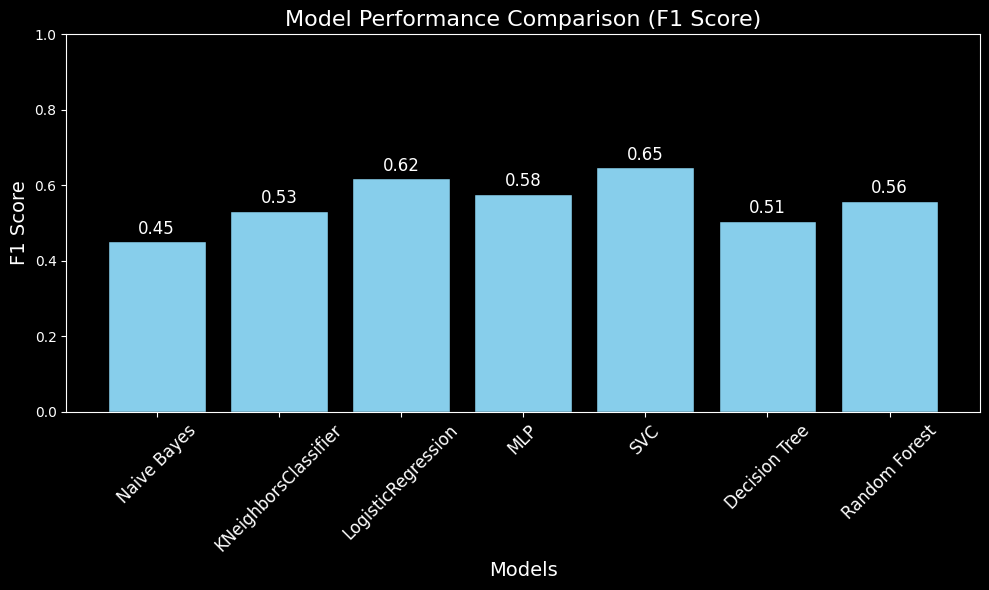

In [52]:
import matplotlib.pyplot as plt

# Create a bar plot for F1 scores
plt.figure(figsize=(10, 6))
plt.bar(list(f1_scores.keys()), list(f1_scores.values()), color='skyblue', edgecolor='black')

# Add titles and labels
plt.title("Model Performance Comparison (F1 Score)", fontsize=16)
plt.xlabel("Models", fontsize=14)
plt.ylabel("F1 Score", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.ylim(0, 1)  # F1 scores range from 0 to 1

# Display F1 scores on the bars
for index, (model, score) in enumerate(f1_scores.items()):
    plt.text(index, score + 0.02, f"{score:.2f}", ha='center', fontsize=12)

# Show plot
plt.tight_layout()
plt.show()


Baseline results indicate strong performance from SVC, with small differences among top models.


## 5. Prediction File Preparation

Preprocess test data and produce submission-ready predictions.


In [53]:
import pandas as pd


# Replace 'your_file.csv' with the name of your CSV file
test_df = pd.read_csv('test.csv')

In [54]:
ID_test = test_df.iloc[:, 0]  # save the ID column in a variable



test_df_date_id = test_df.drop(columns=['ID']) #drop the ID columns
test_df_date_id['Date'] = pd.to_datetime(test_df_date_id['Date'], errors='coerce').dt.month # keeps only month data and converts it to a 1-12 scale



num_features_test = df_date_id.select_dtypes(include=['float64', 'int64']).columns
cat_features_test = df_date_id.select_dtypes(include=['object']).columns

# Define transformers for missing values
numeric_transformer_test = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Replace NaN with mean for numerical columns
    ('scaler', StandardScaler())                  # Scale numerical data
])
categorical_transformer_test = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Replace NaN with most frequent value for categorical columns
    ('encoder', OneHotEncoder(handle_unknown='ignore'))    # One-hot encode categorical data
])

# Reuse the training preprocessor to keep feature mapping consistent.
transformed_test_df_date_id = preprocessor.transform(test_df_date_id)
transformed_test_df_date_id = transformed_test_df_date_id.toarray() if hasattr(transformed_test_df_date_id, 'toarray') else transformed_test_df_date_id

Use only the best-performing model for final test-set inference.


In [55]:

best_model = classifiers['MLP']  
y_test_pred = best_model.predict(transformed_test_df_date_id)  

# Display predictions
print("Predictions for the test set:")
print(y_test_pred)




Predictions for the test set:
[0 0 0 ... 0 1 0]


Export predictions to CSV with exactly two columns:

- `ID`
- `Prediction`


In [56]:
output_df = pd.DataFrame({
    "ID": ID_test,        # The IDs from the test set
    "Prediction": y_test_pred  # The predictions
})

# Save the combined DataFrame to a CSV file
output_df.to_csv('predictions_baseline.csv', index=False)

## 6. Hyperparameter Optimization

Use `GridSearchCV` with 5-fold cross-validation to tune each classifier.


In [57]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grids for each classifier
param_grids = {
    "Naive Bayes": {},  # Naive Bayes has no major hyperparameters to tune
 # Naive Bayes calculates the probability of each class given the input features. The formula is based on the assumption that each feature is independent, meaning the presence of one feature doesn't affect the others. The classifier then selects the class with the highest probability. It s trained by estimating the probability of each feature for every class, often using the frequencies in the training data. It's simple, fast, and effective, especially when features are conditionally independent.
    "KNeighborsClassifier": {
        "n_neighbors": [3, 5, 7, 9],  # Number of neighbors to use
        "metric": ["euclidean", "manhattan"],  # Distance metrics
    },
 # The "n_neighbors" parameter controls how many nearby data points the classifier considers when making a prediction. I selected values 3, 5, 7, and 9 to explore how different numbers of neighbors impact the model s accuracy and generalization.
#
 # The "metric" parameter defines the distance function used to measure the closeness between data points. "euclidean" is the most common metric, measuring straight-line distance, while "manhattan" measures the sum of absolute differences. Testing these metrics allows us to find the one that best fits the data's distribution.
    "LogisticRegression": {
        "C": [0.01, 0.1, 1, 10],  # Inverse of regularization strength
        "solver": ["liblinear", "lbfgs"],  # Optimization algorithm
    },
    
 # The "C" parameter controls the strength of regularization. A smaller value means stronger regularization, which helps prevent overfitting but may lead to underfitting. Larger values reduce regularization, which can improve performance on training data but might cause overfitting. I selected values 0.01, 0.1, 1, and 10 to test different regularization strengths and determine which works best for the dataset.

 # The "solver" parameter specifies the optimization algorithm used to fit the model. "liblinear" is suited for smaller datasets and works well for binary classification, while "lbfgs" is more efficient for larger datasets and supports multinomial classification. Testing both solvers helps identify which one performs better with the data.
    
    
    "MLPClassifier": {
        "hidden_layer_sizes": [(50,), (100,), (50, 50)],  # Size of hidden layers
        "activation": ["relu", "tanh"],  # Activation functions
        "solver": ["adam", "sgd"],  # Optimization solvers
        "alpha": [0.0001, 0.001, 0.01],  # L2 regularization term
    },
    
 # The "hidden_layer_sizes" parameter defines the number of neurons in the hidden layers. I selected (50,), (100,), and (50, 50) to test different network architectures. A single hidden layer with 50 or 100 neurons may capture different complexities, while (50, 50) tests a deeper architecture with two layers, which can potentially model more intricate patterns.

 # The "activation" parameter determines the activation function used in the neurons. "relu" is often preferred for its efficiency and ability to handle vanishing gradients, while "tanh" can work better for certain types of data by centering the output between -1 and 1. Testing both allows comparison of their impact on performance.
 # 
 # The "solver" parameter defines the optimization algorithm. "adam" is generally faster and better for large datasets, while "sgd" (stochastic gradient descent) provides more control but can be slower. Trying both allows us to find the best fit for the dataset.
 # 
 # The "alpha" parameter controls the strength of L2 regularization, which helps prevent overfitting. I selected values like 0.0001, 0.001, and 0.01 to explore different levels of regularization and see how it impacts the model's generalization.
    "SVC": {
        "C": [0.1, 1, 10],  # Regularization parameter
        "kernel": ["linear", "rbf"],  # Kernel types
        "gamma": ["scale", "auto"],  # Kernel coefficient
    },
    
 # The "C" parameter controls the regularization strength. A smaller value (e.g., 0.1) means stronger regularization, which can prevent overfitting but might lead to underfitting. A larger value (e.g., 10) reduces regularization, allowing the model to fit the training data more closely. I selected values 0.1, 1, and 10 to test how regularization affects the model's generalization.

 # The "kernel" parameter defines the type of decision boundary the classifier will use. "linear" is used for linearly separable data, while "rbf" (radial basis function) can handle non-linear data by mapping it into higher-dimensional space. Testing both helps identify which kernel type works better for the data.
 # 
 # The "gamma" parameter defines the influence of a single training example. "scale" (1 / (n_features * X.var())) is generally preferred as it adjusts automatically based on the data, while "auto" (1 / n_features) uses a simpler approach. Testing both gives insight into which gamma setting provides better model performance.
    
    
    "Decision Tree": {
        "max_depth": [None, 10, 20, 30],  # Maximum depth of the tree
        "criterion": ["gini", "entropy"],  # Splitting criterion
    },
    
 # The "max_depth" parameter controls the maximum depth of the tree. A value of None allows the tree to grow until all leaves are pure, which could lead to overfitting. Setting specific depths like 10, 20, and 30 limits the tree s growth, helping prevent overfitting and improving generalization. Testing these values allows us to find the right tree depth for the data.

 # The "criterion" parameter determines how the tree splits nodes. "gini" is the default measure based on the Gini impurity, while "entropy" measures the information gain at each split. Both are common choices for decision trees, and testing them helps identify which splitting criterion leads to better model performance for the given dataset.
    
    
    "Random Forest": {
        "n_estimators": [50, 100, 200],  # Number of trees in the forest
        "max_depth": [None, 10, 20],  # Maximum depth of the trees
        "criterion": ["gini", "entropy"],  # Splitting criterion
    },
    
 #The "n_estimators" parameter defines the number of trees in the forest. I selected 50, 100, and 200 to test how the number of trees affects model performance. More trees can lead to better accuracy, but too many can increase computational cost without significant improvement.

 # The "max_depth" parameter limits the depth of each tree in the forest. With values like None, 10, and 20, I can test how restricting the depth affects model performance. Deeper trees may overfit, while limiting depth can help improve generalization.
 # 
 # The "criterion" parameter defines the splitting method used by the trees. "gini" measures the Gini impurity, and "entropy" measures the information gain. Testing both allows us to find the splitting criterion that best suits the dataset for better accuracy and stability in the random forest. 
}

# Dictionary to store the best models after optimization
best_models_test = {}

# Loop through each classifier
for name, model in classifiers.items():
    print(f"Optimizing {name}...")
    
 # Retrieve the parameter grid for the current classifier
    param_grid = param_grids.get(name, {})
    
 # Perform GridSearchCV only if there are hyperparameters to tune
    if param_grid: # checks if the dict is empty
 # Set up GridSearchCV with 5-fold cross-validation
        grid_search = GridSearchCV(
            estimator=model,  # Classifier to optimize
            param_grid=param_grid,  # Hyperparameter grid
            scoring="f1",  # F1 score as the evaluation metric
            cv=5,  # 5-fold cross-validation
            n_jobs=-1,  # Use all available CPU cores
            verbose=2  # Output progress
        )
        
 # Fit GridSearchCV using the training data
        grid_search.fit(X_train_dense, y_train)

 # Store the best model found in the dictionary
        best_models_test[name] = grid_search.best_estimator_
        
 # Print the best parameters for the current model
        print(f"Best parameters for {name}: {grid_search.best_params_}")
    else:
 # If no hyperparameters to tune, simply use the default model
        best_models_test[name] = model
        print(f"No parameters to tune for {name}. Using default settings.")

Optimizing Naive Bayes...
No parameters to tune for Naive Bayes. Using default settings.
Optimizing KNeighborsClassifier...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ....................metric=euclidean, n_neighbors=3; total time=   0.1s
[CV] END ....................metric=euclidean, n_neighbors=5; total time=   0.1s
[CV] END ....................metric=euclidean, n_neighbors=3; total time=   0.1s
[CV] END ....................metric=euclidean, n_neighbors=3; total time=   0.1s
[CV] END ....................metric=euclidean, n_neighbors=5; total time=   0.1s
[CV] END ....................metric=euclidean, n_neighbors=3; total time=   0.1s
[CV] END ....................metric=euclidean, n_neighbors=5; total time=   0.1s
[CV] END ....................metric=euclidean, n_neighbors=3; total time=   0.1s
[CV] END ....................metric=euclidean, n_neighbors=5; total time=   0.1s
[CV] END ....................metric=euclidean, n_neighbors=5; total time=   0.1s
[CV] E

### 6.a Validation prediction with tuned models

Run validation inference using the best estimator from each grid search.


In [58]:
# Dictionary to store predictions for each optimized model
validation_predictions = {}


# Loop through each optimized model
for name, model in best_models_test.items():
    print(f"Making predictions with {name}...")
    
 # Use the model to predict labels for the validation set features
 # This does not use y_test, only X_test (features)
    predictions_test = model.predict(X_val_dense)
    
 # Store predictions in the dictionary
    validation_predictions[name] = predictions_test

    

Making predictions with Naive Bayes...
Making predictions with KNeighborsClassifier...
Making predictions with LogisticRegression...
Making predictions with MLP...
Making predictions with SVC...
Making predictions with Decision Tree...
Making predictions with Random Forest...


### 6.b Post-tuning F1 comparison

Compare tuned models by validation F1 score.


In [59]:
from sklearn.metrics import f1_score

# Dictionary to store F1 scores for each model
f1_scores = {}

# Loop through each model and its predictions
for name, predictions in validation_predictions.items():
    print(f"Evaluating {name}...")
    
 # Calculate the F1 score by comparing predictions with actual validation labels
    score = f1_score(y_val, predictions, average="weighted")  # Weighted F1 score for multiclass problems
    
 # Store the F1 score in the dictionary
    f1_scores[name] = score
    
 # Display the F1 score
    print(f"F1 Score for {name}: {score:.4f}")

# Sort and display the F1 scores for all models in descending order
sorted_f1_scores = dict(sorted(f1_scores.items(), key=lambda item: item[1], reverse=True))
print("\nF1 Scores for all models (sorted):")
for model, score in sorted_f1_scores.items():
    print(f"{model}: {score:.4f}")

Evaluating Naive Bayes...
F1 Score for Naive Bayes: 0.6573
Evaluating KNeighborsClassifier...
F1 Score for KNeighborsClassifier: 0.8140
Evaluating LogisticRegression...
F1 Score for LogisticRegression: 0.8048
Evaluating MLP...
F1 Score for MLP: 0.8221
Evaluating SVC...
F1 Score for SVC: 0.8250
Evaluating Decision Tree...
F1 Score for Decision Tree: 0.7879
Evaluating Random Forest...
F1 Score for Random Forest: 0.8297

F1 Scores for all models (sorted):
Random Forest: 0.8297
SVC: 0.8250
MLP: 0.8221
KNeighborsClassifier: 0.8140
LogisticRegression: 0.8048
Decision Tree: 0.7879
Naive Bayes: 0.6573


### 6.c Performance visualization

Plot tuned-model F1 scores for final comparison.


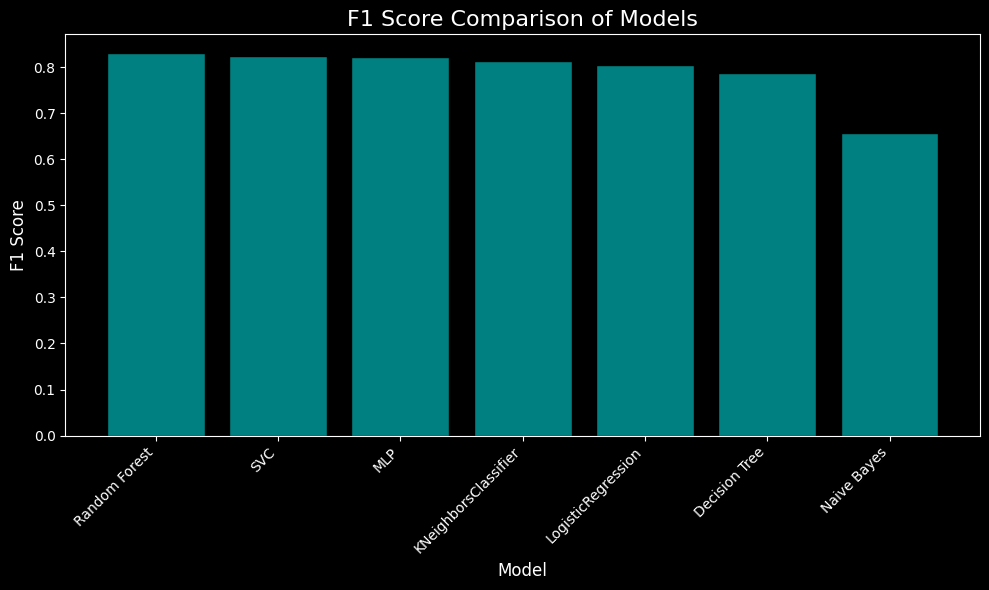

In [60]:
import matplotlib.pyplot as plt

# Create a bar plot for the F1 scores
plt.figure(figsize=(10, 6))
plt.bar(list(sorted_f1_scores.keys()), list(sorted_f1_scores.values()), color="teal", edgecolor="black")

# Add titles and labels
plt.title("F1 Score Comparison of Models", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("F1 Score", fontsize=12)
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for readability

# Display the plot
plt.tight_layout()
plt.show()

## 7. Final Test Predictions

Select the best tuned model and generate final test predictions.


Run inference on preprocessed test features using the selected best model.


In [61]:
# my best model is Random Forest


best_model_veltisto = best_models_test['Random Forest']
 # This gets the best model from grid search

# Now you can use the best model to make predictions on your test data
y_test_pred_veltisto = best_model_veltisto.predict(transformed_test_df_date_id)  # Replace with scaled data if necessary

# Display predictions
print("Predictions for the test set:")
print(y_test_pred_veltisto)







Predictions for the test set:
[1 0 0 ... 0 0 0]


Save final predictions in the required two-column CSV format: `ID`, `Prediction`.


In [62]:
veltisto_prediction_9_df = pd.DataFrame({
    "ID": ID_test,        # The IDs from the test set
    "Prediction": y_test_pred_veltisto  # The predictions
})

# Save the combined DataFrame to a CSV file
veltisto_prediction_9_df.to_csv('predictions_tuned.csv', index=False)
